# PADL coursework

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from gensim.models import Word2Vec

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, accuracy_score
from scipy.stats import mode

import torch
import torch.nn as nn
from torch import optim

/Users/elijah/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Q1

### A

In [ ]:
# Get data from PADL-Q11-train.csv
data = np.loadtxt('datasets/PADL-Q11-train.csv', delimiter=',', skiprows=1)

# Split data into features and targets
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5)

# Standardise X values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_val_scaled = scaler.transform(X_val)

# Create polynomial features
poly = PolynomialFeatures(degree=2)  
X_poly = poly.fit_transform(X_scaled)
# X_val_poly = poly.transform(X_val_scaled) 

# Linear regression model
model = LinearRegression()
model.fit(X_poly, y)
# y_pred = model.predict(X_val_poly)
# lin_r2 = r2_score(y_val, y_pred)


LinearRegression()

### B

In [80]:
# Get data from PADL-Q12-train.csv
data = np.loadtxt('datasets/PADL-Q12-train.csv', delimiter=',', skiprows=1)

# Split data into X and y 
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8)

# Standardise X values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_scaled)
r2_lr = r2_score(y_val, y_pred_lr)

# Display the coefficients and R² for the generic Linear Regression model
print(f"Linear Regression Coefficients: {lr_model.coef_}")
print(f"Linear Regression R²: {r2_lr:.4f}")

# Now with regularised models
# Start off with declaring alpha values 
alphas = [10, 1, 0.1, 0.01, 0.001, 1e-3, 1e-4]

# Initialize lists to store R² scores and coefficients for Ridge and Lasso
ridge_r2_scores = []
lasso_r2_scores = []
ridge_coeffs = []
lasso_coeffs = []

Linear Regression Coefficients: [17.55315215  8.88027268 14.45783128  0.75877445]
Linear Regression R²: 0.9566


### C

In [14]:
# Get data from PADL-Q13-train.csv
data = np.loadtxt('datasets/PADL-Q13-train.csv', delimiter=',', skiprows=1)

# Split data into X and y 
X = data[:, :-1]
y = data[:, -1]

# # Split the available data into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train a linear regression model to act as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)
r2_lr = r2_score(y_val, y_pred_lr)

# Standardise features and apply pca
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train model with standardised data
lr_model_with_preprocessing = LinearRegression()
lr_model_with_preprocessing.fit(X_train_scaled, y_train)
y_pred_with_preprocessing = lr_model_with_preprocessing.predict(X_val_scaled)
r2_with_preprocessing = r2_score(y_val, y_pred_with_preprocessing)

# Display results
print(f"R² without preprocessing: {r2_lr:.4f}")
print(f"R² with preprocessing: {r2_with_preprocessing:.4f}")

R² without preprocessing: 0.9681
R² with preprocessing: 0.9681


## Q2

### A

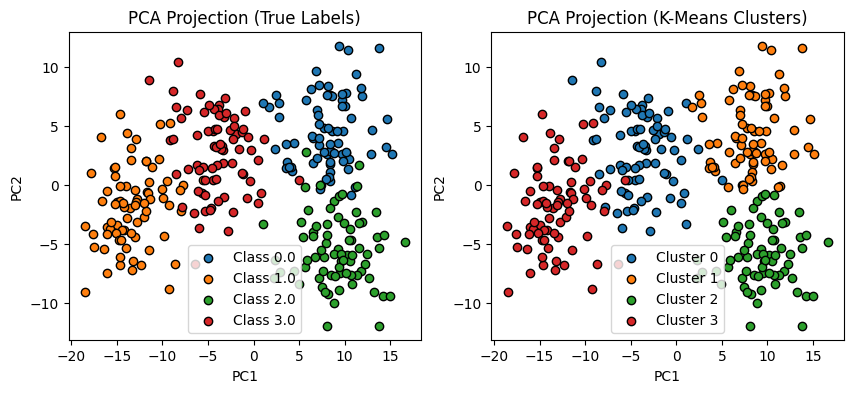

In [15]:
# Load data from PADL-Q2.csv
data = np.loadtxt('datasets/PADL-Q2.csv', delimiter=',', skiprows=1)

# Extract into features and labels
X = data[:, :-1]
Y = data[:, -1]

# Might need standardising or normalisation

# Define number of clusters
num_clusters = len(np.unique(Y))

# K-means on original data
kmeans = KMeans(n_clusters=num_clusters)
Y_kmeans = kmeans.fit_predict(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create figure
plt.figure(figsize=(10,4))

# Plot PCA with true labels
plt.subplot(1, 2, 1)
for label in np.unique(Y):
    plt.scatter(X_pca[Y == label, 0], X_pca[Y == label, 1], label=f"Class {label}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (True Labels)")
plt.legend()

# Plot PCA projection with K-Means Clusters
plt.subplot(1, 2, 2)
for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans == cluster, 0], X_pca[Y_kmeans == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (K-Means Clusters)")
plt.legend()

### B

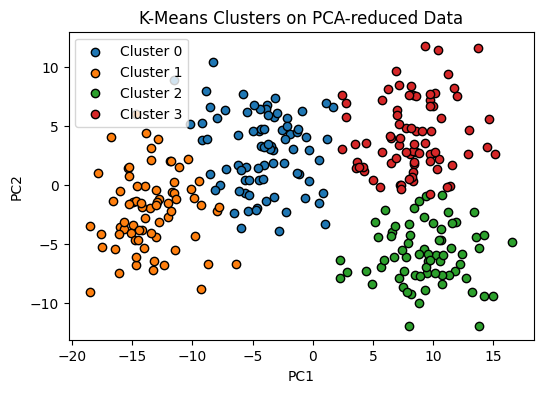

In [16]:
# Apply K-means to PCA data
kmeans_pca = KMeans(n_clusters=num_clusters)
Y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Plot predictions from kmeans after PCA
plt.figure(figsize=(6, 4))

for cluster in range(num_clusters):
    plt.scatter(X_pca[Y_kmeans_pca == cluster, 0], X_pca[Y_kmeans_pca == cluster, 1], label=f"Cluster {cluster}", edgecolor="k")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-reduced Data")
plt.legend()
plt.show()

### C

## Q3

### A

In [47]:
# Load data from PADL-Q3.txt
with open('datasets/PADL-Q3.txt', 'r') as f:
    sentences = [line.strip().split() for line in f]

# Train a Skip-gram Word2Vec model
model = Word2Vec(sentences=sentences, sg=1)
word_embeddings = model.wv

# Cosine similarities betweeen node 5 and nodes 21 - 30
print("Similarities with node 5:")
for i in range(21, 31):
    try:
        sim = word_embeddings.similarity("5", str(i))
        print(f"Node 5 <-> Node {i}: {sim:.4f}")
    except KeyError:
        print(f"Node {i} not in vocabulary.")


Similarities with node 5:
Node 5 <-> Node 21: 0.1919
Node 5 <-> Node 22: 0.1497
Node 5 <-> Node 23: 0.2954
Node 5 <-> Node 24: 0.3021
Node 5 <-> Node 25: 0.2017
Node 5 <-> Node 26: 0.1908
Node 5 <-> Node 27: 0.2411
Node 5 <-> Node 28: 0.2294
Node 5 <-> Node 29: 0.1964
Node 5 <-> Node 30: 0.1898


### B

## Q4

### A

### B

In [142]:
# Get data from body_measurements.csv
data = np.genfromtxt('datasets/body_measurements.csv', delimiter=',', skip_header=1, filling_values=np.nan)

# Filter out nan values
valid_rows = ~np.isnan(data).any(axis=1) 
data_clean = data[valid_rows]

# Split data into features and labels
X = data_clean[:, :-1]
y = data_clean[:, -1]

# Split into train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4)

# Preprocesing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform the training data
X_val_scaled = scaler.transform(X_val)  # Transform the validation data using the same scaler

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# Model
class WaistPredictor(nn.Module):
    def __init__(self):
        super(WaistPredictor, self).__init__()
        self.MLP = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),
            # nn.Linear(128, 64),       
            # nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.MLP(x)

# Define model parameters
model = WaistPredictor()
loss_func = nn.MSELoss()
val_loss_func = nn.L1Loss()
optimiser = optim.Adam(model.parameters(), lr = 0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=10, verbose=True)


/Users/elijah/Library/Python/3.9/lib/python/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Train MSE: 1808.95, Val MAE: 32.69
Epoch 2, Train MSE: 1808.95, Val MAE: 32.69
Epoch 3, Train MSE: 1808.95, Val MAE: 32.69
Epoch 4, Train MSE: 1808.95, Val MAE: 32.69
Epoch 5, Train MSE: 1808.95, Val MAE: 32.69
Epoch 6, Train MSE: 1808.95, Val MAE: 32.69
Epoch 7, Train MSE: 1808.95, Val MAE: 32.69
Epoch 8, Train MSE: 1808.95, Val MAE: 32.69
Epoch 9, Train MSE: 1808.95, Val MAE: 32.69
Epoch 10, Train MSE: 1808.95, Val MAE: 32.69
Epoch 11, Train MSE: 1808.95, Val MAE: 32.69
Epoch 12, Train MSE: 1808.95, Val MAE: 32.69
Epoch 13, Train MSE: 1808.95, Val MAE: 32.69
Epoch 14, Train MSE: 1808.95, Val MAE: 32.69
Epoch 15, Train MSE: 1808.95, Val MAE: 32.69
Epoch 16, Train MSE: 1808.95, Val MAE: 32.69
Epoch 17, Train MSE: 1808.95, Val MAE: 32.69
Epoch 18, Train MSE: 1808.95, Val MAE: 32.69
Epoch 19, Train MSE: 1808.95, Val MAE: 32.69
Epoch 20, Train MSE: 1808.95, Val MAE: 32.69
Epoch 21, Train MSE: 1808.95, Val MAE: 32.69
Epoch 22, Train MSE: 1808.95, Val MAE: 32.69
Epoch 23, Train MSE

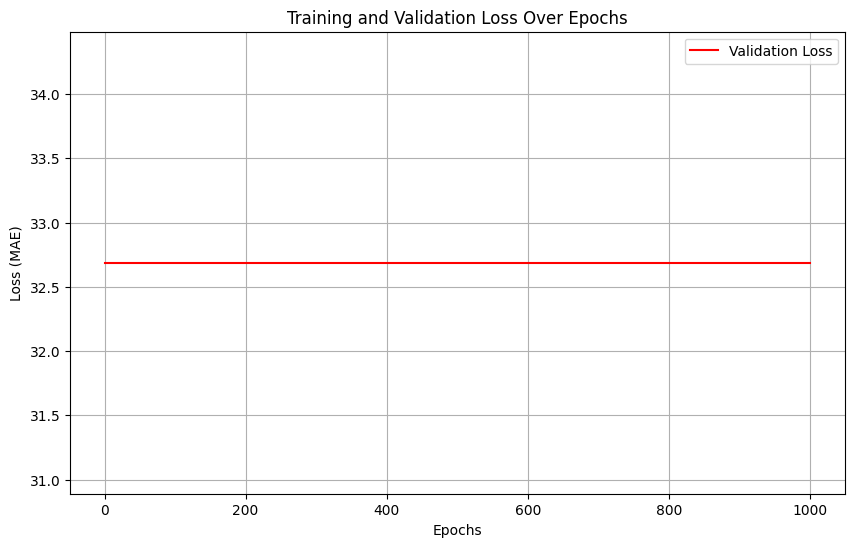

In [146]:
# Get rid of these
train_losses = []
val_losses = []

# Training loop
for epoch in range(1000):
    model.train()
    optimiser.zero_grad()
    outputs = model(X_train_tensor)
    loss = loss_func(outputs, y_train_tensor)
     
    loss.backward()
    optimiser.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = val_loss_func(val_outputs, y_val_tensor)
       

    # Get rid of this   
    train_losses.append(loss.item())  
    val_losses.append(val_loss.item())
    
    print(f"Epoch {epoch+1}, Train MSE: {loss.item():.2f}, Val MAE: {val_loss.item():.2f}")
    scheduler.step(val_loss.item())

# Function to calculate the number of parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    return total_params

# Calculate and print the number of parameters
total_params = count_parameters(model)
print(f"Total number of parameters: {total_params}")


# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
# plt.plot(range(1, 1001), train_losses, label="Train Loss", color='blue')
plt.plot(range(1, 1001), val_losses, label="Validation Loss", color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## Q5

### A

### B

## Q6

### A

### B

### C